# Financial Inclusion in Africa Starter Notebook


This is a simple starter notebook to get started with the Financial Inclusion Competition on Zindi.

This notebook covers:
- Loading the data
- Simple EDA and an example of feature enginnering
- Data preprocessing and data wrangling
- Creating a simple model
- Making a submission
- Some tips for improving your score

In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Importing libraries

In [106]:
# dataframe and plotting
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from google.colab import files
import warnings
warnings.filterwarnings('ignore')

### 1. Load the dataset

In [107]:
# Load files into a pandas dataframe
path="/content/drive/MyDrive/Data/"
train = pd.read_csv(path+'Train.csv')
test = pd.read_csv(path+'Test.csv')
ss = pd.read_csv(path+'SampleSubmission.csv')
variables = pd.read_csv(path+'VariableDefinitions.csv')

In [108]:
# Let’s observe the shape of our datasets.
print('train data shape :', train.shape)
print('test data shape :', test.shape)

train data shape : (23524, 13)
test data shape : (10086, 12)


The above output shows the number of rows and columns for train and test dataset. We have 13 variables in the train dataset, 12 independent variables and 1 dependent variable. In the test dataset, we have 12 independent variables.

We can observe the first five rows from our data set by using the head() method from the pandas library.

In [109]:
# inspect train data
train.head(10)

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed
5,Kenya,2018,uniqueid_6,No,Rural,No,7,26,Female,Spouse,Married/Living together,Primary education,Informally employed
6,Kenya,2018,uniqueid_7,No,Rural,Yes,7,32,Female,Spouse,Married/Living together,Primary education,Self employed
7,Kenya,2018,uniqueid_8,No,Rural,Yes,1,42,Female,Head of Household,Married/Living together,Tertiary education,Formally employed Government
8,Kenya,2018,uniqueid_9,Yes,Rural,Yes,3,54,Male,Head of Household,Married/Living together,Secondary education,Farming and Fishing
9,Kenya,2018,uniqueid_10,No,Urban,Yes,3,76,Female,Head of Household,Divorced/Seperated,No formal education,Remittance Dependent


In [110]:
# Check for missing values
print(train.isnull().sum().sort_values(ascending=False))

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


We don't have missing data in our dataset.



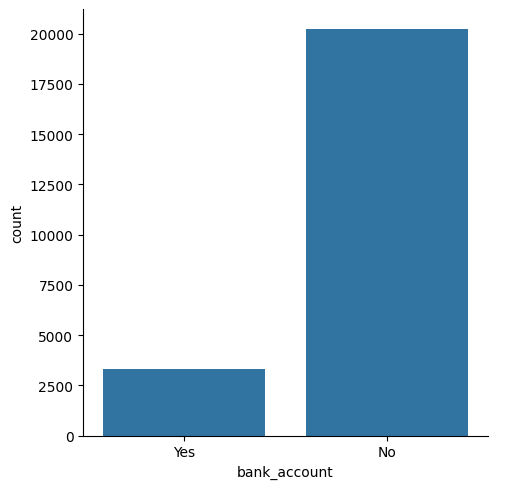

In [111]:
# Explore Target distribution
sns.catplot(x="bank_account", kind="count", data=train)

### 2. Understand the dataset
We can get more information about the features presented by using the info() method from pandas.


In [112]:
 #show some information about the dataset
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB
None


The output shows the list of variables/features, sizes, if it contains missing values and data type for each variable. From the dataset, we don’t have any missing values and we have 3 features of integer data type and 10 features of the object data type.

If you want to learn how to handle missing data in your dataset, we recommend you read How to [Handle Missing Data with Python](https://machinelearningmastery.com/handle-missing-data-python/) by Jason Brownlee.

We won’t go further on understanding the dataset because Davis has already published an article about exploratory data analysis (EDA) with the financial Inclusion in Africa dataset. You can read and download the notebook for EDA in the link below.

[Why you need to explore your data and how you can start](https://https://medium.com/analytics-vidhya/why-you-need-to-explore-your-data-how-you-can-start-13de6f29c8c1)

In [113]:
# Let's view the variables
variables

,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...


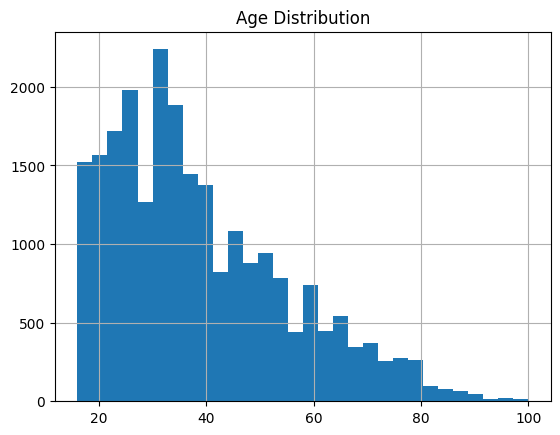

In [114]:
train["age_of_respondent"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

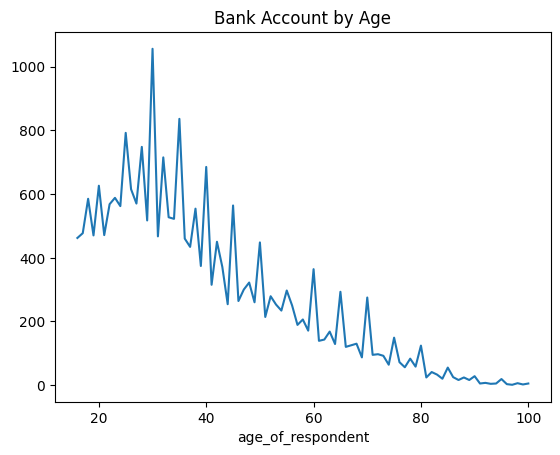

In [115]:
train.groupby("age_of_respondent")["bank_account"].count().plot()
plt.title("Bank Account by Age")
plt.show()

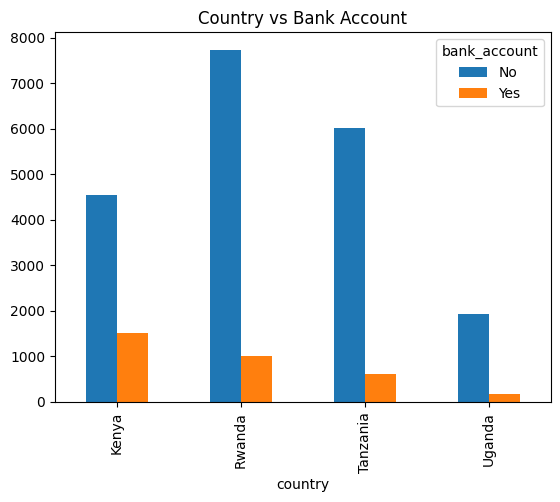

In [116]:
train.groupby("country")["bank_account"].value_counts().unstack().plot(kind="bar")
plt.title("Country vs Bank Account")
plt.show()

In [117]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train["bank_account"] = le.fit_transform(train["bank_account"])

Observe the first row in the train data.

Observe the shape of the train data.

In [118]:
# Make copies to avoid messing original data
train_df = train.copy()
test_df = test.copy()

In [119]:


# =========================
# SAFE FEATURE ENGINEERING
# =========================

for df in [train_df, test_df]:

    # 1. Urban + phone access (strong signal)
    df["urban_phone"] = (
        (df["location_type"] == "Urban") &
        (df["cellphone_access"] == "Yes")
    ).astype(int)




    df["educated_employed"] = (
        (df["education_level"] != "No formal education") &
        (df["job_type"] != "No Income")
    ).astype(int)

    # 2. Age grouping
    df["age_group"] = pd.cut(
        df["age_of_respondent"],
        bins=[0, 18, 25, 35, 50, 100],
        labels=[0, 1, 2, 3, 4]
    )

    # 3. Household grouping
    df["household_group"] = pd.cut(
        df["household_size"],
        bins=[0, 2, 4, 6, 10, 50],
        labels=[0, 1, 2, 3, 4]
    )

    df["young_educated"] = (
        (df["age_of_respondent"] < 35) &
        (df["education_level"].isin([
            "Secondary education",
            "Tertiary education",
            "Vocational/Specialised training"
        ]))
    ).astype(int)

    df["stable_income"] = (
        df["job_type"].isin([
            "Formally employed Private",
            "Formally employed Government",
            "Self employed"
        ])
    ).astype(int)

    df["financial_maturity"] = (
        (df["age_of_respondent"] >= 30) &
        (df["age_of_respondent"] <= 55)
    ).astype(int)






In [120]:
X = train_df.drop(["bank_account", "uniqueid"], axis=1)
y = train_df["bank_account"]

test_features = test_df.drop(["uniqueid"], axis=1)

In [121]:
X_train = X
y_train = y

In [122]:
X_train = pd.get_dummies(X_train)
test_features = pd.get_dummies(test_features)

X_train, test_features = X_train.align(
    test_features,
    join="left",
    axis=1,
    fill_value=0
)

In [123]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=1300,
    learning_rate=0.018,
    max_depth=4,
    subsample=0.88,
    colsample_bytree=0.88,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    min_child_weight=1,
    random_state=42
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.88, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.018, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1300,
              n_jobs=None, num_parallel_tree=None, ...)

In [124]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

weak_features = importance[importance < 0.0015].index

X_train = X_train.drop(columns=weak_features)
test_features = test_features.drop(columns=weak_features, errors="ignore")

In [125]:
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.88, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.018, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1300,
              n_jobs=None, num_parallel_tree=None, ...)

<Axes: >

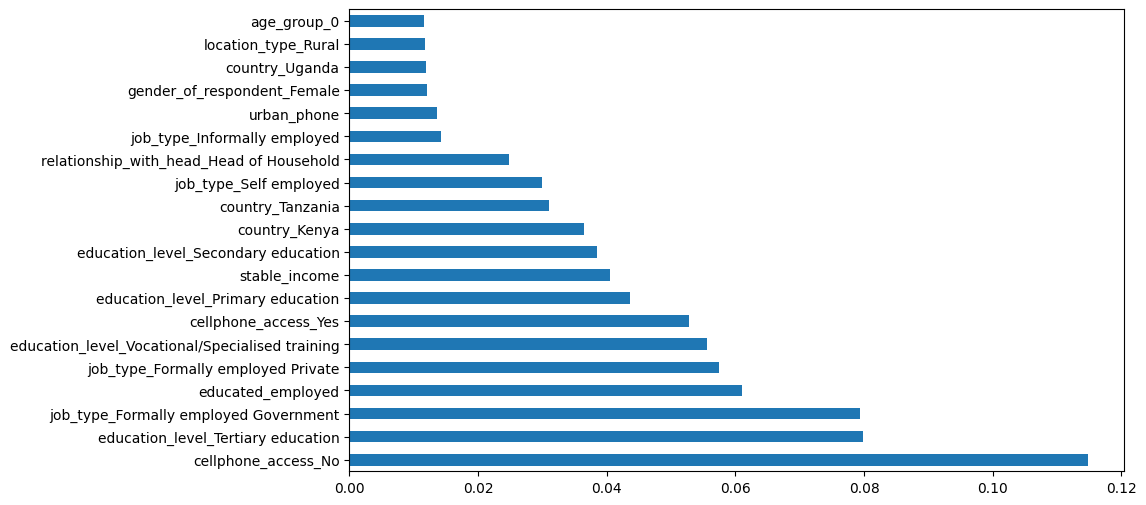

In [126]:

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance.nlargest(20).plot(kind="barh", figsize=(10,6))

In [127]:
test_ids = test["uniqueid"] + " x " + test["country"]

In [128]:
test_preds = model.predict(test_features)

In [129]:
submission = pd.DataFrame({
    "uniqueid": test["uniqueid"] + " x " + test["country"],
    "bank_account": test_preds
})

submission.to_csv("submission.csv", index=False)
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>